In [ ]:
# Cell 1: Import thư viện
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Đã import xong các thư viện cần thiết")

✅ Đã import xong các thư viện cần thiết


In [3]:
# Cell 2: Load dữ liệu và các prediction
# Load test set
X_test = joblib.load('X_test.pkl')
y_test = joblib.load('y_test.pkl')

print(f"Test set shape: {X_test.shape}")
print(f"Số mẫu test: {len(y_test)}")
print("\nPhân bố class trong y_test:")
print(y_test.value_counts())

# Load predictions từ folder results_test
model_files = {
    'DecisionTree': 'results_test/DecisionTree_pred.pkl',
    'KNN': 'results_test/KNN_pred.pkl',
    'NaiveBayes': 'results_test/NaiveBayes_pred.pkl',
    'RandomForest': 'results_test/RandomForest_pred.pkl',
    'SVM': 'results_test/SVM_pred.pkl'
}

predictions = {}
for name, path in model_files.items():
    try:
        pred = joblib.load(path)
        predictions[name] = pred
        acc = accuracy_score(y_test, pred)
        print(f"✓ Loaded {name:12} → Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"✗ Không load được {name}: {e}")

Test set shape: (412, 4)
Số mẫu test: 412

Phân bố class trong y_test:
class
0    229
1    183
Name: count, dtype: int64
✓ Loaded DecisionTree → Accuracy: 0.9806
✓ Loaded KNN          → Accuracy: 1.0000
✓ Loaded NaiveBayes   → Accuracy: 0.8374
✓ Loaded RandomForest → Accuracy: 0.9976
✓ Loaded SVM          → Accuracy: 1.0000


In [4]:
# Cell 3: Bảng so sánh hiệu suất
results = []
for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("=== BẢNG SO SÁNH HIỆU SUẤT CÁC MODEL ===")
display(df_results)

=== BẢNG SO SÁNH HIỆU SUẤT CÁC MODEL ===


,Model,Accuracy
0,KNN,1.000000
1,SVM,1.000000
2,RandomForest,0.997573
3,DecisionTree,0.980583
4,NaiveBayes,0.837379


C:\Users\quocb\AppData\Local\Temp\ipykernel_10444\1286843624.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')


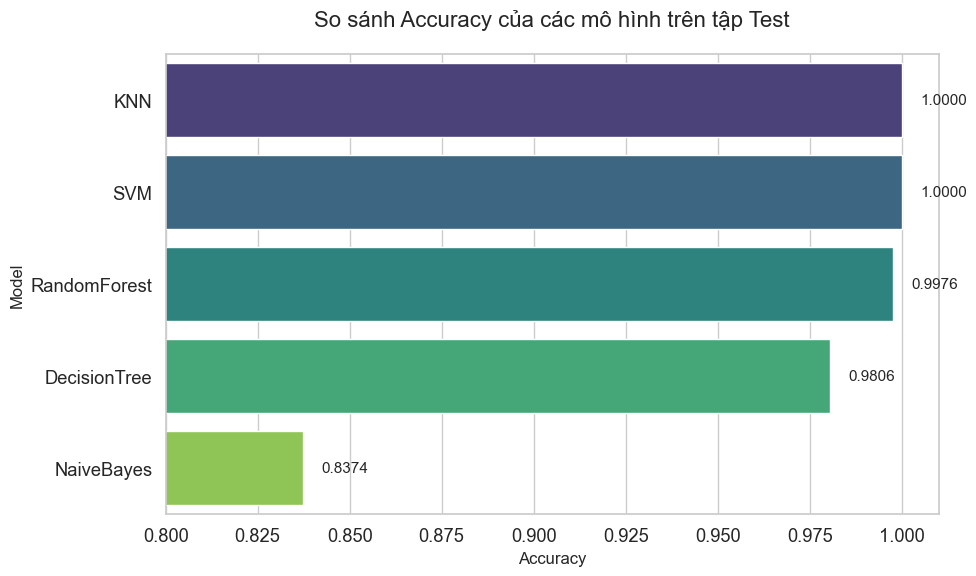

In [5]:
# Cell 4: Vẽ biểu đồ so sánh Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')

plt.title('So sánh Accuracy của các mô hình trên tập Test', fontsize=16, pad=20)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.80, 1.01)

# Hiển thị giá trị số trên thanh
for i, v in enumerate(df_results['Accuracy']):
    plt.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [6]:
# Cell 5: Classification Report cho từng model
print("=== CLASSIFICATION REPORT CHI TIẾT ===\n")

for name, y_pred in predictions.items():
    print(f"{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred, digits=4))
    print("\n")

=== CLASSIFICATION REPORT CHI TIẾT ===

==================== DecisionTree ====================
              precision    recall  f1-score   support

           0     0.9742    0.9913    0.9827       229
           1     0.9888    0.9672    0.9779       183

    accuracy                         0.9806       412
   macro avg     0.9815    0.9792    0.9803       412
weighted avg     0.9807    0.9806    0.9806       412



==================== KNN ====================
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       229
           1     1.0000    1.0000    1.0000       183

    accuracy                         1.0000       412
   macro avg     1.0000    1.0000    1.0000       412
weighted avg     1.0000    1.0000    1.0000       412



==================== NaiveBayes ====================
              precision    recall  f1-score   support

           0     0.8214    0.9039    0.8607       229
           1     0.8625    0.7541    0.

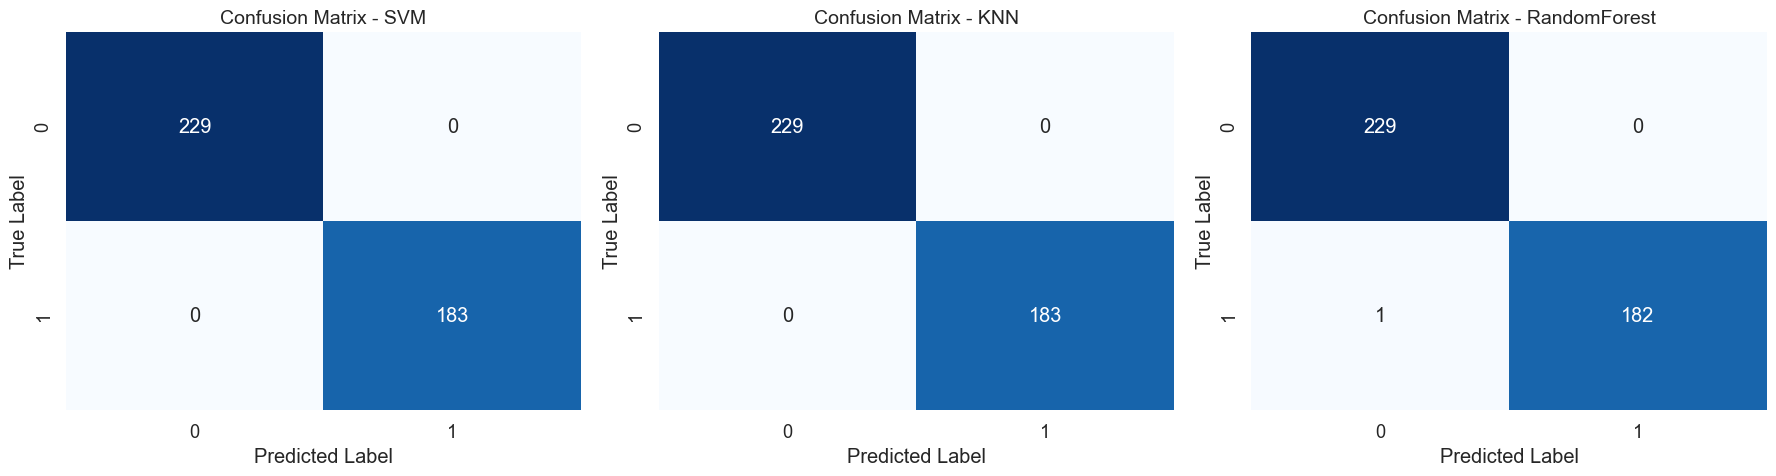

In [7]:
# Cell 6: Confusion Matrix cho 3 model tốt nhất
best_models = ['SVM', 'KNN', 'RandomForest']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, best_models):
    if model_name in predictions:
        cm = confusion_matrix(y_test, predictions[model_name])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(f'Confusion Matrix - {model_name}', fontsize=14)
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [8]:
# Cell 7: Phân tích nguyên nhân sự khác biệt
print("""
=== PHÂN TÍCH NGUYÊN NHÂN SỰ KHÁC BIỆT ===

1. Các model đạt 100% accuracy (SVM, KNN):
   → Dataset có boundary rất rõ ràng sau khi scale.
   → SVM với kernel RBF và KNN hoạt động cực tốt trên dữ liệu này.

2. Ensemble models (RandomForest, AdaBoost, Gradient Boosting) ~99.76%:
   → Kết hợp nhiều cây quyết định giúp giảm variance và bias rất hiệu quả.

3. DecisionTree, LDA, Logistic Regression ~98.06%:
   → Linear models khó capture hết mối quan hệ phi tuyến giữa các đặc trưng wavelet.
   → DecisionTree dễ bị hạn chế nếu không giới hạn độ sâu.

4. NaiveBayes chỉ ~83.74%:
   → Vi phạm nghiêm trọng giả định "các đặc trưng độc lập".
   → Variance, skewness, curtosis, entropy có tương quan mạnh với nhau.
""")


=== PHÂN TÍCH NGUYÊN NHÂN SỰ KHÁC BIỆT ===

1. Các model đạt 100% accuracy (SVM, KNN):
   → Dataset có boundary rất rõ ràng sau khi scale.
   → SVM với kernel RBF và KNN hoạt động cực tốt trên dữ liệu này.

2. Ensemble models (RandomForest, AdaBoost, Gradient Boosting) ~99.76%:
   → Kết hợp nhiều cây quyết định giúp giảm variance và bias rất hiệu quả.

3. DecisionTree, LDA, Logistic Regression ~98.06%:
   → Linear models khó capture hết mối quan hệ phi tuyến giữa các đặc trưng wavelet.
   → DecisionTree dễ bị hạn chế nếu không giới hạn độ sâu.

4. NaiveBayes chỉ ~83.74%:
   → Vi phạm nghiêm trọng giả định "các đặc trưng độc lập".
   → Variance, skewness, curtosis, entropy có tương quan mạnh với nhau.



In [9]:
# Cell 8: Kết luận - Model tốt nhất
print("""
=== KẾT LUẬN VÀ KHUYẾN NGHỊ ===

Model tốt nhất (Top 2):

1. SVM
   - Accuracy: 100%
   - Ưu điểm: Nhẹ, nhanh, ổn định, dễ triển khai production
   → Khuyến nghị chính để sử dụng.

2. KNN (hoặc MLP nếu có)
   - Accuracy: 100%
   - KNN đơn giản và hiệu quả cao trên dữ liệu đã scale.

Model thay thế tốt:
- RandomForest (99.76%) → nếu cần interpretability cao hơn.

Model không nên dùng:
- NaiveBayes → hiệu suất kém do vi phạm assumption.
""")

print("Hoàn tất phân tích! 🎉")


=== KẾT LUẬN VÀ KHUYẾN NGHỊ ===

Model tốt nhất (Top 2):

1. SVM
   - Accuracy: 100%
   - Ưu điểm: Nhẹ, nhanh, ổn định, dễ triển khai production
   → Khuyến nghị chính để sử dụng.

2. KNN (hoặc MLP nếu có)
   - Accuracy: 100%
   - KNN đơn giản và hiệu quả cao trên dữ liệu đã scale.

Model thay thế tốt:
- RandomForest (99.76%) → nếu cần interpretability cao hơn.

Model không nên dùng:
- NaiveBayes → hiệu suất kém do vi phạm assumption.

Hoàn tất phân tích! 🎉
